# Autoencoder Anomaly Detection - Evaluation & Visualization

This notebook evaluates trained autoencoder models for anomaly detection on the KDD Cup 99 dataset.

All metrics, tables, and plots are computed and rendered directly inline in the notebook
below — nothing is written to the `results/` directory. Simply run the notebook top to
bottom to see the full evaluation.

## Environment Setup

Load required libraries and configure the project path for consistent imports.

In [25]:

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path.cwd().parent / 'src'))

from data_preprocessing import load_data, resolve_project_root
from evaluate import (
    calculate_reconstruction_error,
    select_anomaly_threshold,
    predict_anomalies,
    compute_anomaly_metrics,
    plot_reconstruction_error_distribution,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_reconstruction_error_vs_index,
    plot_threshold_sensitivity,
    plot_reconstruction_error_distribution_comparison,
    plot_confusion_matrix_comparison,
    plot_precision_recall_curve_comparison,
    plot_reconstruction_error_vs_index_comparison,
    plot_threshold_sensitivity_comparison,
    build_evaluation_report,
)
from model import build_autoencoder
from train import set_global_seed

# Global configuration
PERCENTILE = 95.0

# Set global seeds for reproducibility
set_global_seed(69)

# Initialize project paths (models/data are read-only inputs; nothing is written to disk)
project_root = resolve_project_root()
data_dir = project_root / "data" / "processed"
models_dir = project_root / "models"

print(f"Project Root: {project_root}")
print(f"Data Dir: {data_dir}")
print(f"Models Dir: {models_dir}")
print(f"Percentile: {PERCENTILE}")

Project Root: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection
Data Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/data/processed
Models Dir: /Users/kallestewart/Github/SEP740-CourseProject-G9-P19-AnomalyDetection/models
Percentile: 95.0


## Data Loading

Load the preprocessed training and test datasets for optimization experiments.

In [26]:
print("Loading data...")

# Load train and test tables
train_data_path = data_dir / "train.csv"
test_data_path = data_dir / "test.csv"

train_set = load_data(train_data_path)
test_set = load_data(test_data_path)

print("Train Set:")
display(train_set.head())
print("Test Set:")
display(test_set.head())

# Convert labels to numeric classes expected by sklearn metrics
label_to_int = {"normal": 0, "anomaly": 1}

feature_cols = [c for c in train_set.columns if c not in ["label", "binary_label"]]
X_train_df = train_set[feature_cols]
X_test_df = test_set[feature_cols]

y_train_series = train_set["binary_label"].map(label_to_int)
y_test_series = test_set["binary_label"].map(label_to_int)

if y_train_series.isna().any() or y_test_series.isna().any():
    raise ValueError("Unexpected values found in binary_label. Expected only 'normal' and 'anomaly'.")

# Default source: arrays built from CSV
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)
y_train = y_train_series.to_numpy(dtype=np.int32)
y_test = y_test_series.to_numpy(dtype=np.int32)
source = "CSV-derived arrays"

print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}")

Loading data...
Train Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.026526,-0.092098,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
1,-0.145561,-0.026472,-0.051431,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
2,-0.145561,-0.026689,-0.086207,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
3,-0.145561,-0.026173,-0.066131,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.025901,0.015446,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False


Test Set:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
1,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False
2,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,True,False,False,False,False,False,False,False,False,False
3,-0.145561,-0.029163,-0.080533,0.0,0.0,0.0,-0.053347,-0.010067,0.510313,-0.008538,...,False,False,False,False,False,False,False,False,True,False
4,-0.145561,-0.035007,-0.098556,0.0,0.0,0.0,-0.053347,-0.010067,-1.959581,-0.008538,...,False,False,False,False,True,False,False,False,False,False


Train Set Shape: (61482, 118), Labels Shape: (61482,)
Test Set Shape: (84104, 118), Labels Shape: (84104,)


## Model Loading & Comparison
Load and evaluate all available models. Every model's reconstruction errors, threshold,
predictions, and metrics are cached in `model_data` so that sections 1-8 below can compare
**all** models side-by-side. The single best model (by F1-score) is also selected for the
architecture summary that follows.

Evaluating model: autoencoder_best_model_v2.keras
Evaluating model: autoencoder_best_model_v3.keras
Evaluating model: autoencoder_best_model_v1.keras
Evaluating model: autoencoder_baseline_model.keras

Model Comparison Results:


,model_name,threshold,accuracy,precision,recall,f1_score
0,autoencoder_best_model_v2.keras,0.011223,0.975756,0.977593,0.987326,0.982435
1,autoencoder_best_model_v3.keras,0.001488,0.980096,0.978090,0.993265,0.985619
2,autoencoder_best_model_v1.keras,0.013061,0.976541,0.977553,0.988538,0.983014
3,autoencoder_baseline_model.keras,0.892315,0.949955,0.977152,0.949320,0.963035


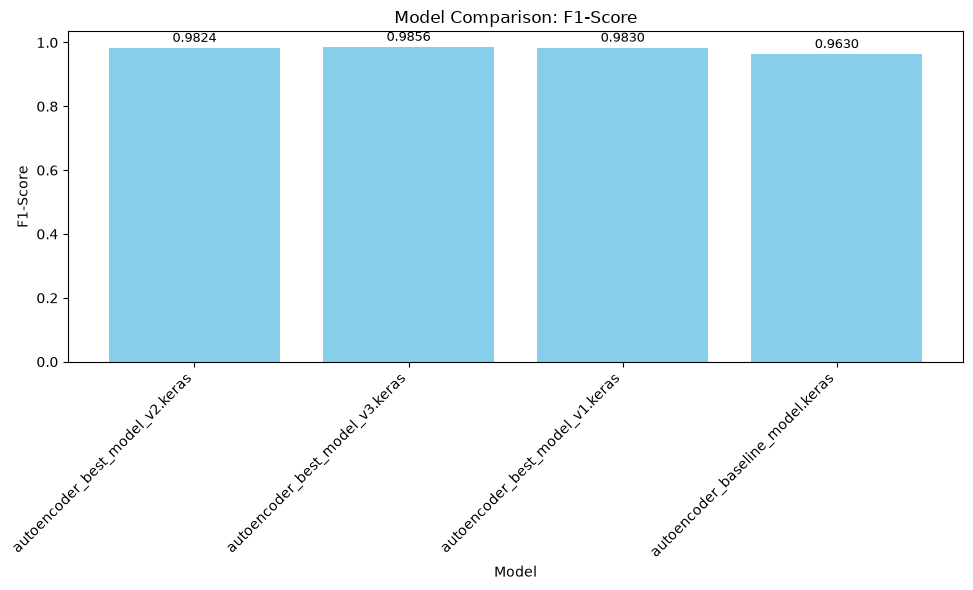


Selected best model for subsequent sections: autoencoder_best_model_v3.keras (F1-Score: 0.9856)


In [ ]:
# Find all .keras files in the models directory and subdirectories
# (excluding best_overall_model.keras
EXCLUDED_MODEL_FILENAMES = {'best_overall_model.keras'}
model_paths = [
    p for p in models_dir.rglob("*.keras")
    if p.name not in EXCLUDED_MODEL_FILENAMES
]
model_names = [str(p.relative_to(models_dir)) for p in model_paths]

# Sort models by name for consistent ordering
results = []
model_data = {}

for model_path, model_name in zip(model_paths, model_names):
    print(f"Evaluating model: {model_name}")
    try:
        m = tf.keras.models.load_model(model_path)

        # Compute reconstruction errors on training set
        train_errors = calculate_reconstruction_error(m, X_train)
        # Determine threshold using the specified percentile on training errors
        threshold = select_anomaly_threshold(train_errors, percentile=PERCENTILE)

        # Compute reconstruction errors on test set
        test_errors = calculate_reconstruction_error(m, X_test)
        # Predict anomalies on test set
        y_pred = predict_anomalies(test_errors, threshold)

        # Compute metrics
        metrics = compute_anomaly_metrics(y_test, y_pred)

        # Store summary results
        results.append({
            'model_name': model_name,
            'model_path': str(model_path),
            'threshold': threshold,
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1_score': metrics['f1_score'],
            'confusion_matrix': metrics['confusion_matrix']
        })

        # Store everything needed for the per-model comparisons in sections 1-8
        model_data[model_name] = {
            'model_path': model_path,
            'train_errors': train_errors,
            'test_errors': test_errors,
            'threshold': threshold,
            'y_pred': y_pred,
            'y_test': y_test,
            'metrics': metrics,
        }
    except Exception as e:
        print(f"Error evaluating model {model_name}: {e}")
        # Store NaN values for failed models
        results.append({
            'model_name': model_name,
            'model_path': str(model_path),
            'threshold': np.nan,
            'accuracy': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1_score': np.nan,
            'confusion_matrix': None
        })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)

# Identify the baseline model (we assume the baseline is named 'autoencoder_baseline_model.keras')
baseline_model_name = 'autoencoder_baseline_model.keras'
baseline_result = results_df[results_df['model_name'] == baseline_model_name]
if not baseline_result.empty:
    baseline_metrics = baseline_result.iloc[0]
    # Calculate improvement over baseline for each model
    results_df['accuracy_improvement'] = results_df['accuracy'] - baseline_metrics['accuracy']
    results_df['precision_improvement'] = results_df['precision'] - baseline_metrics['precision']
    results_df['recall_improvement'] = results_df['recall'] - baseline_metrics['recall']
    results_df['f1_score_improvement'] = results_df['f1_score'] - baseline_metrics['f1_score']
else:
    # If baseline not found, set improvements to NaN
    results_df['accuracy_improvement'] = np.nan
    results_df['precision_improvement'] = np.nan
    results_df['recall_improvement'] = np.nan
    results_df['f1_score_improvement'] = np.nan
    print(f"Warning: Baseline model '{baseline_model_name}' not found in models directory.")

# Display the results table
print("\nModel Comparison Results:")
display(results_df[['model_name', 'threshold', 'accuracy', 'precision', 'recall', 'f1_score']])

# Plot a bar chart comparing F1 scores
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(results_df)), results_df['f1_score'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('Model Comparison: F1-Score')
plt.xticks(range(len(results_df)), results_df['model_name'], rotation=45, ha='right')
# Add value labels on top of bars
for bar, f1 in zip(bars, results_df['f1_score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{f1:.4f}', 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Select the best model based on F1-score for use in the subsequent sections
if not results_df['f1_score'].isna().all():
    best_model_idx = results_df['f1_score'].idxmax()
    best_model_name = results_df.loc[best_model_idx, 'model_name']
    best_model_path = results_df.loc[best_model_idx, 'model_path']
    model = tf.keras.models.load_model(best_model_path)
    print(f"\nSelected best model for subsequent sections: {best_model_name} (F1-Score: {results_df.loc[best_model_idx, 'f1_score']:.4f})")
else:
    # Fallback to the original method of loading the best_optimized_model
    best_model_path = models_dir / 'best_optimized_model.keras'
    if best_model_path.exists():
        model = tf.keras.models.load_model(best_model_path)
        best_model_name = str(best_model_path.relative_to(models_dir))
        print(f"\nFallback to best_optimized_model: {best_model_path}")
    else:
        # Try to load any model
        for model_path, model_name in zip(model_paths, model_names):
            if model_path.exists():
                model = tf.keras.models.load_model(model_path)
                best_model_path = model_path
                best_model_name = model_name
                print(f"\nFallback to first available model: {model_path}")
                break
        else:
            raise FileNotFoundError("No model found in models directory.")

In [28]:
# Show the architecture of the model selected above for the detailed analysis below
print(f"Using model: {best_model_name}")
model.summary()

Using model: autoencoder_best_model_v3.keras


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 64)             │        23,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 118)            │        23,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,092 (551.14 KB)

 Trainable params: 47,030 (183.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 94,062 (367.43 KB)

# Section 1: Threshold calibration & metrics computation
This section compares the calibrated anomaly threshold and evaluation metrics for
**every** model in a single summary table, ranked by F1-score.

In [29]:
print("=" * 60)
print("THRESHOLD & METRICS COMPARISON - ALL MODELS")
print("=" * 60)

# Single comparison table built from the per-model data cached in model_data
threshold_metrics_df = pd.DataFrame([
    {
        'model_name': model_name,
        'threshold': data['threshold'],
        'accuracy': data['metrics']['accuracy'],
        'precision': data['metrics']['precision'],
        'recall': data['metrics']['recall'],
        'f1_score': data['metrics']['f1_score'],
    }
    for model_name, data in model_data.items()
]).sort_values('f1_score', ascending=False).reset_index(drop=True)

display(threshold_metrics_df)

top_model_name = threshold_metrics_df.iloc[0]['model_name']
print(f"\nTop model by F1-Score: {top_model_name} (F1={threshold_metrics_df.iloc[0]['f1_score']:.6f})")

THRESHOLD & METRICS COMPARISON - ALL MODELS


,model_name,threshold,accuracy,precision,recall,f1_score
0,autoencoder_best_model_v3.keras,0.001488,0.980096,0.978090,0.993265,0.985619
1,autoencoder_best_model_v1.keras,0.013061,0.976541,0.977553,0.988538,0.983014
2,autoencoder_best_model_v2.keras,0.011223,0.975756,0.977593,0.987326,0.982435
3,autoencoder_baseline_model.keras,0.892315,0.949955,0.977152,0.949320,0.963035



Top model by F1-Score: autoencoder_best_model_v3.keras (F1=0.985619)


# Section 2: Error Statisitcs & Distrobusion Analysis
Summarize reconstruction error statistics for every model in a single table, plot the
error distribution histograms (train normal, test normal, test anomaly) for all models
side-by-side in a single comparison figure, and also show each model's individual
full-size distribution plot.

ERROR STATISTICS & DISTRIBUTION COMPARISON - ALL MODELS


,model_name,threshold,train_mean,train_std,test_normal_mean,test_anomaly_mean,pct_train_above_thresh,pct_test_normal_above_thresh,pct_test_anomaly_above_thresh
0,autoencoder_best_model_v2.keras,0.011223,0.003813,0.212460,0.006819,0.544464,5.001464,4.960152,98.732555
1,autoencoder_best_model_v3.keras,0.001488,0.001167,0.076544,0.001579,0.488181,5.001464,4.876660,99.326454
2,autoencoder_best_model_v1.keras,0.013061,0.003470,0.078175,0.007527,0.507802,5.001464,4.975332,98.853759
3,autoencoder_baseline_model.keras,0.892315,0.287070,4.274499,0.334950,98.602196,5.001464,4.865275,94.931953


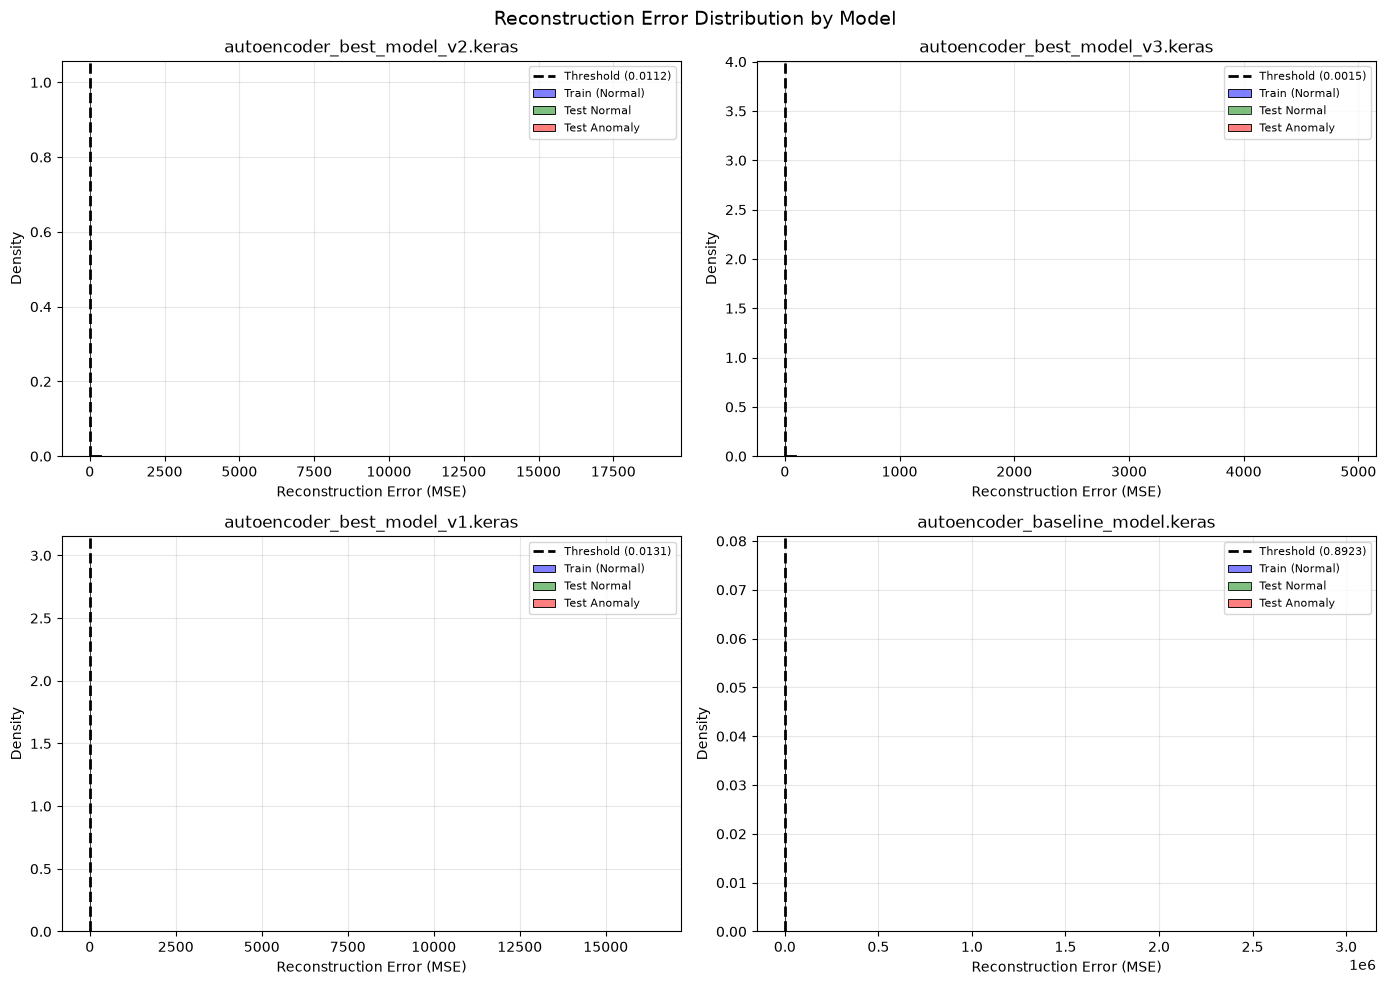


--- autoencoder_best_model_v2.keras ---


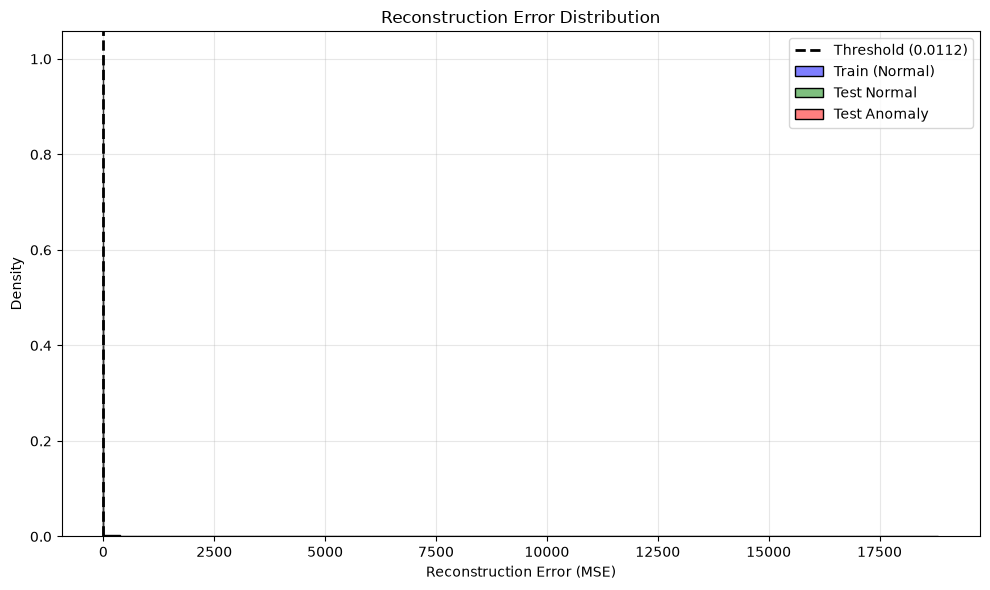


--- autoencoder_best_model_v3.keras ---


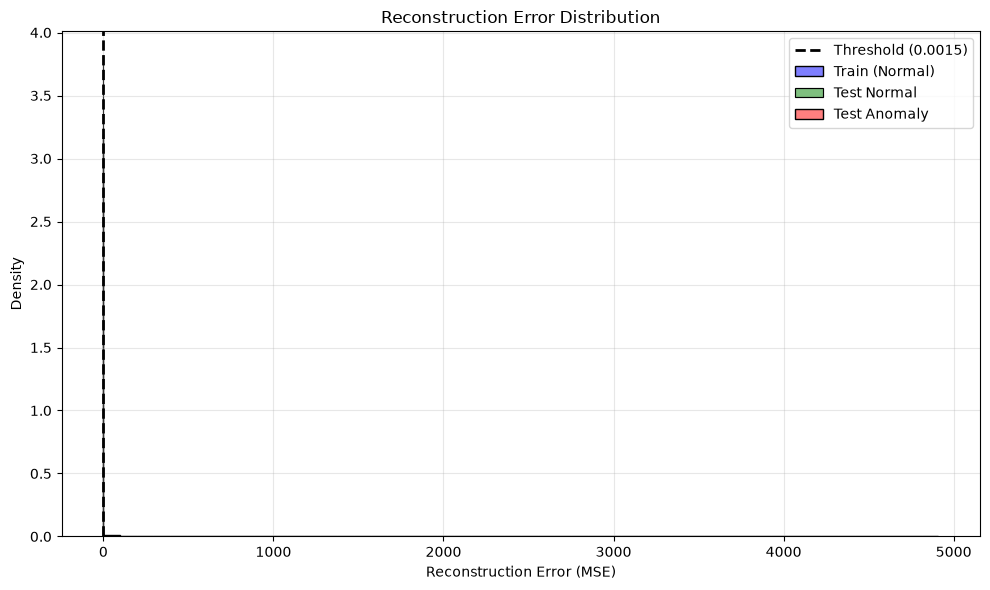


--- autoencoder_best_model_v1.keras ---


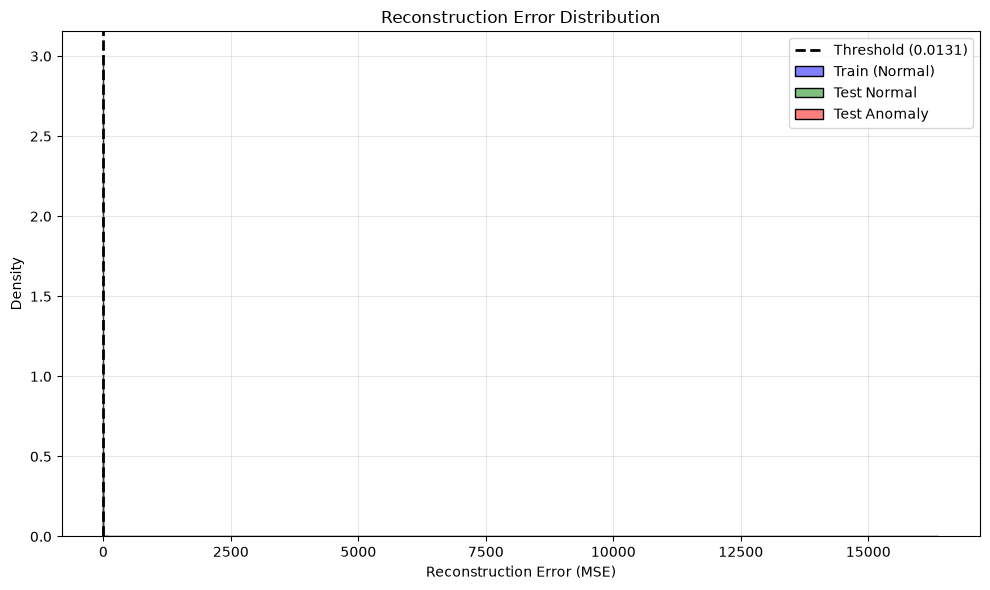


--- autoencoder_baseline_model.keras ---


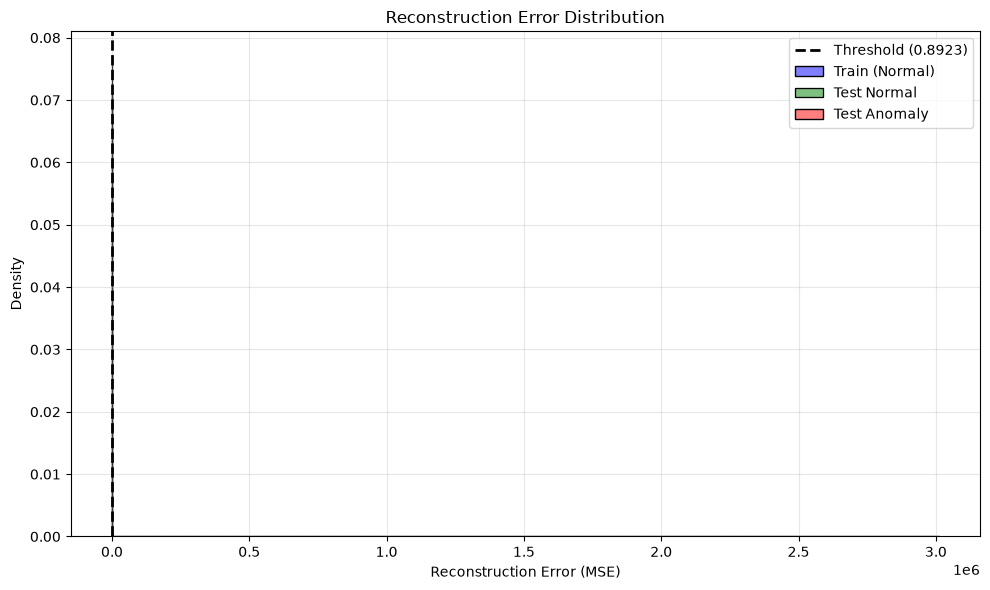

In [30]:
print("=" * 60)
print("ERROR STATISTICS & DISTRIBUTION COMPARISON - ALL MODELS")
print("=" * 60)

# Single summary table of reconstruction error statistics for every model
error_stats_rows = []
for model_name, data in model_data.items():
    train_errors = data['train_errors']
    test_errors = data['test_errors']
    y_test_m = data['y_test']
    threshold = data['threshold']
    test_normal = test_errors[y_test_m == 0]
    test_anomaly = test_errors[y_test_m == 1]

    error_stats_rows.append({
        'model_name': model_name,
        'threshold': threshold,
        'train_mean': np.mean(train_errors),
        'train_std': np.std(train_errors),
        'test_normal_mean': np.mean(test_normal),
        'test_anomaly_mean': np.mean(test_anomaly),
        'pct_train_above_thresh': 100 * np.mean(train_errors > threshold),
        'pct_test_normal_above_thresh': 100 * np.mean(test_normal > threshold),
        'pct_test_anomaly_above_thresh': 100 * np.mean(test_anomaly > threshold),
    })

error_stats_df = pd.DataFrame(error_stats_rows)
display(error_stats_df)

# Single comparison figure: one distribution subplot per model
plot_reconstruction_error_distribution_comparison(model_data)

# Individual full-size distribution plot for each model
for model_name, data in model_data.items():
    print(f"\n--- {model_name} ---")
    plot_reconstruction_error_distribution(
        train_errors=data['train_errors'],
        test_errors=data['test_errors'],
        y_test=data['y_test'],
        threshold=data['threshold'],
    )

# Section 3: Confusion Matric
Visualize the confusion matrix as a heatmap for every model, side-by-side in a single
comparison figure, plus each model's individual full-size heatmap.

CONFUSION MATRIX COMPARISON - ALL MODELS


,model_name,TN,FP,FN,TP
0,autoencoder_best_model_v2.keras,25043,1307,732,57022
1,autoencoder_best_model_v3.keras,25065,1285,389,57365
2,autoencoder_best_model_v1.keras,25039,1311,662,57092
3,autoencoder_baseline_model.keras,25068,1282,2927,54827


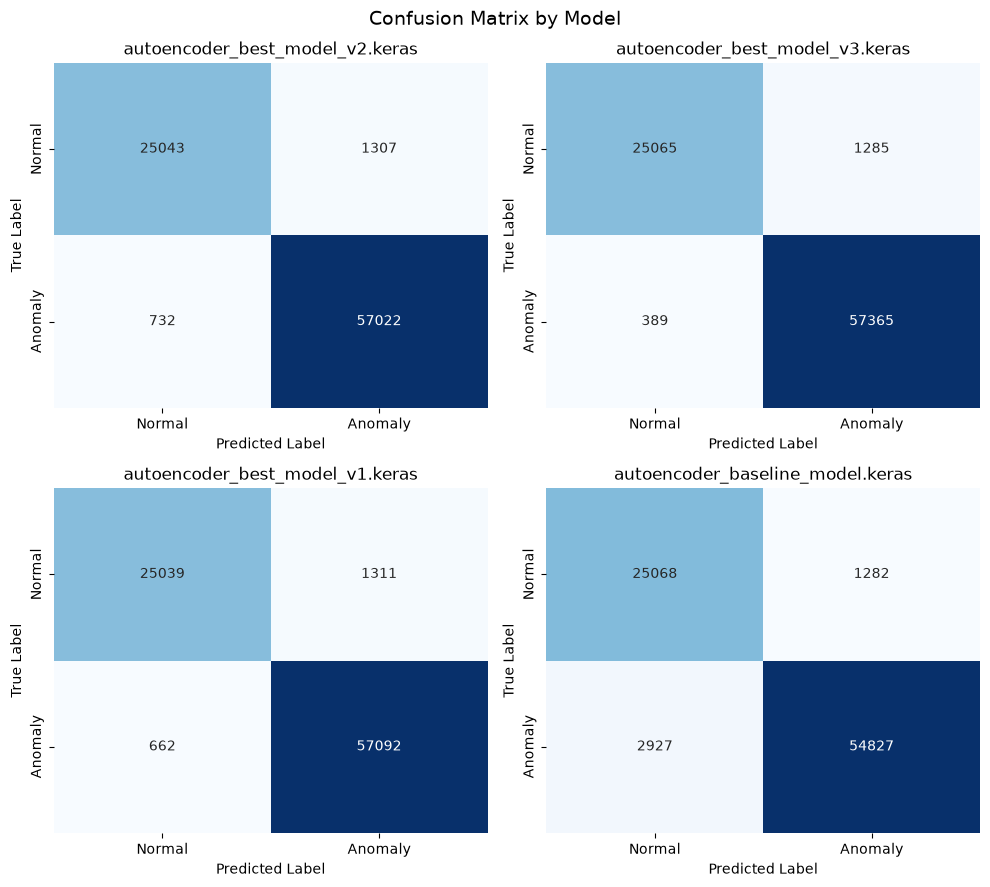


--- autoencoder_best_model_v2.keras ---


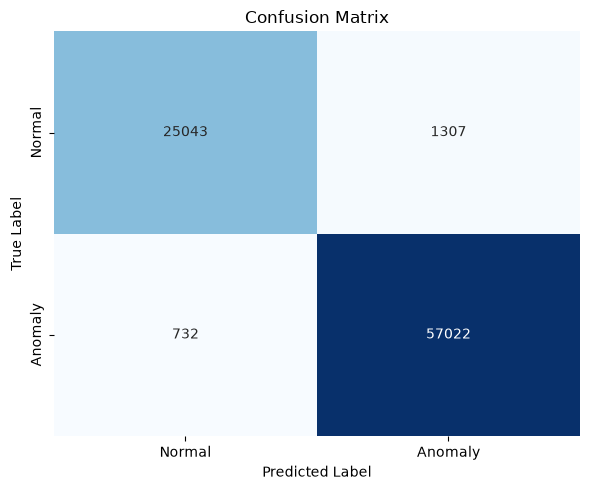


--- autoencoder_best_model_v3.keras ---


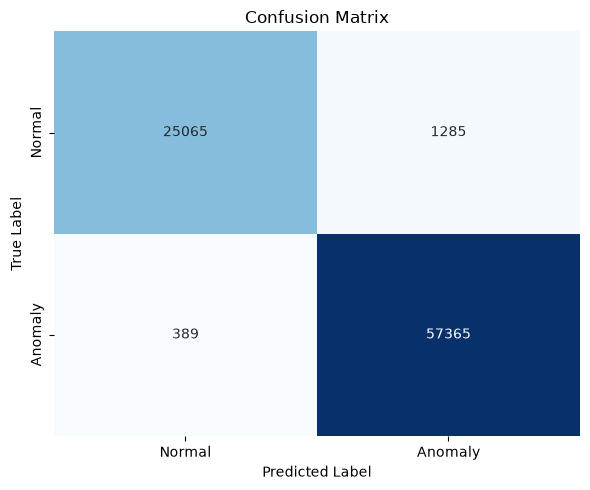


--- autoencoder_best_model_v1.keras ---


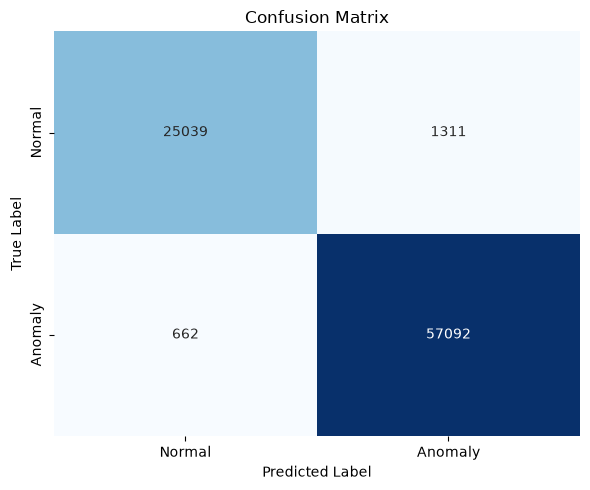


--- autoencoder_baseline_model.keras ---


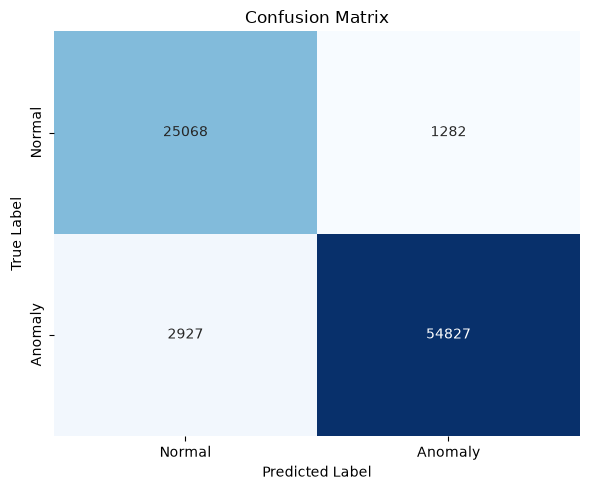

In [31]:
print("=" * 60)
print("CONFUSION MATRIX COMPARISON - ALL MODELS")
print("=" * 60)

# Single summary table of TN/FP/FN/TP counts for every model
cm_rows = []
cms_by_model = {}
for model_name, data in model_data.items():
    cm = data['metrics']['confusion_matrix']
    cms_by_model[model_name] = cm
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({'model_name': model_name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})

display(pd.DataFrame(cm_rows))

# Single comparison figure: one confusion matrix heatmap per model
plot_confusion_matrix_comparison(cms_by_model)

# Individual full-size confusion matrix heatmap for each model
for model_name, cm in cms_by_model.items():
    print(f"\n--- {model_name} ---")
    plot_confusion_matrix(cm)

# Section 4: Precision-Recall Curce 

Overlay the precision-recall curve for every model on a single comparison plot, using
reconstruction errors as anomaly scores, plus each model's individual full-size PR
curve. Each model's current operating point (threshold) is marked on its curve.

PRECISION-RECALL CURVE COMPARISON - ALL MODELS


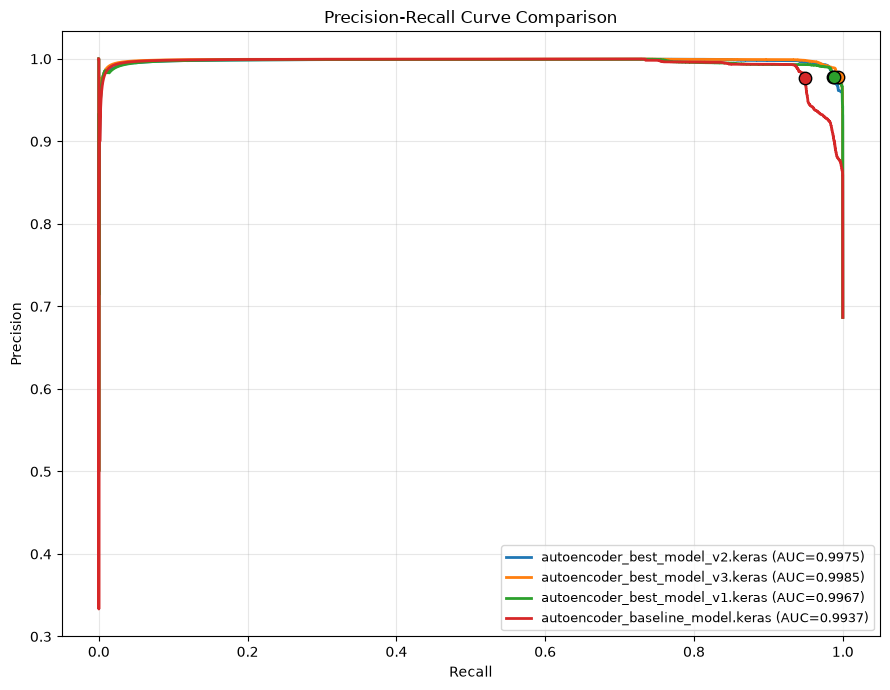


--- autoencoder_best_model_v2.keras ---


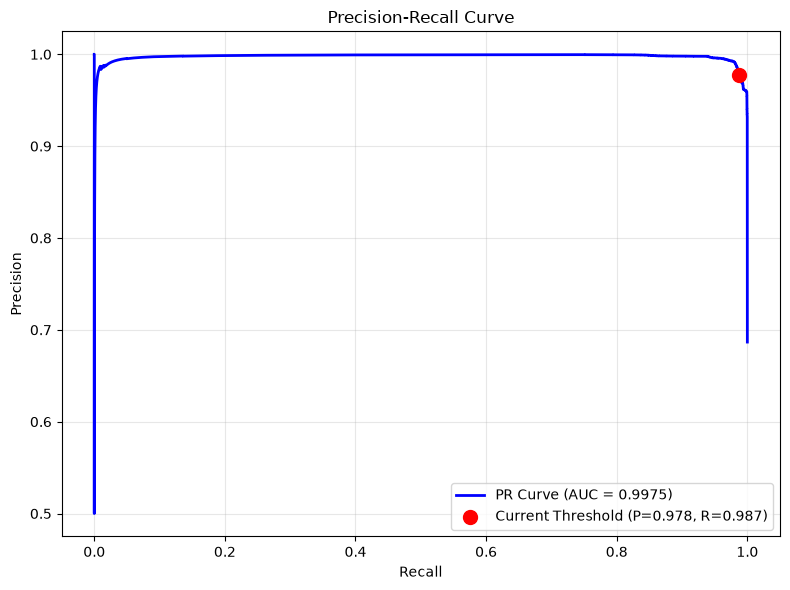


--- autoencoder_best_model_v3.keras ---


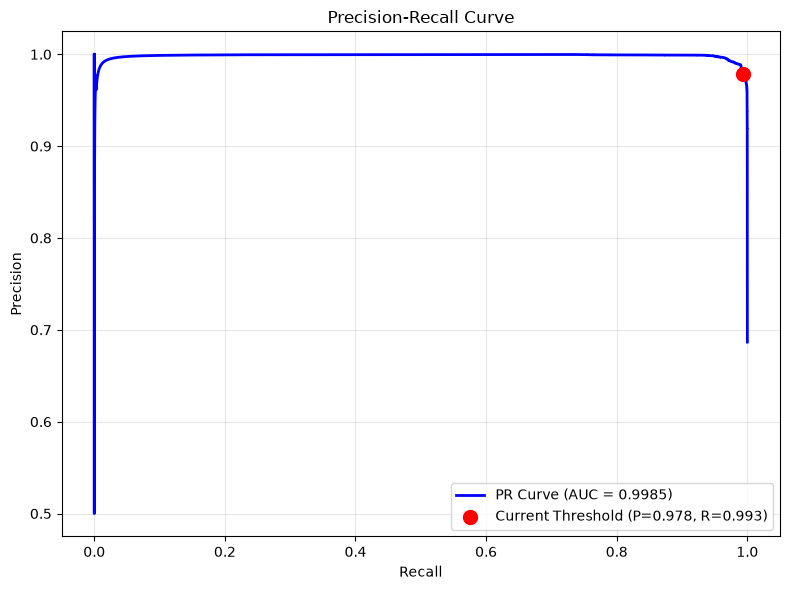


--- autoencoder_best_model_v1.keras ---


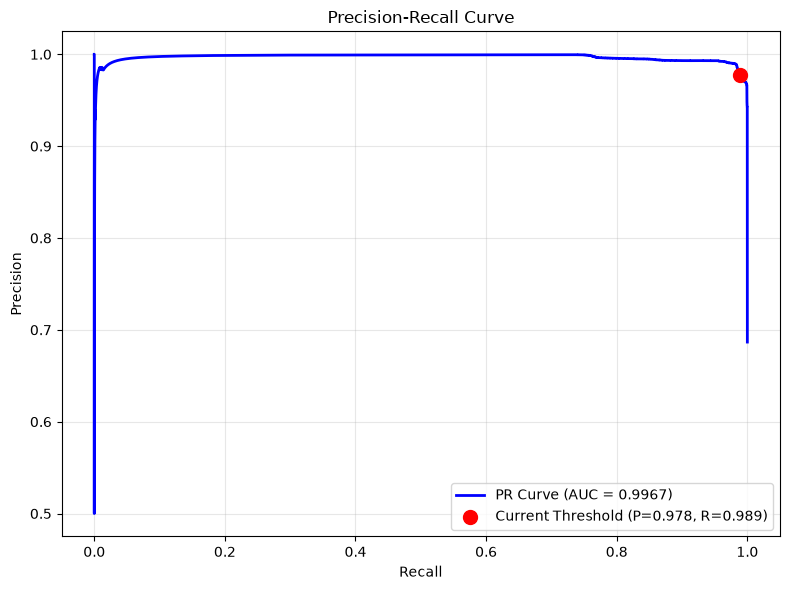


--- autoencoder_baseline_model.keras ---


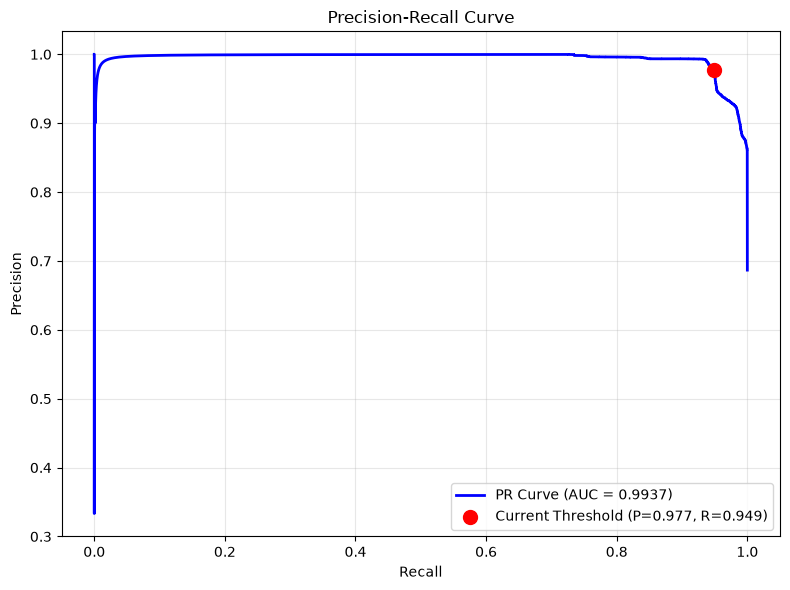

In [32]:
# =============================================================================
# SECTION 4: PRECISION-RECALL CURVE COMPARISON - ALL MODELS
# =============================================================================

print("=" * 60)
print("PRECISION-RECALL CURVE COMPARISON - ALL MODELS")
print("=" * 60)

# Single overlay figure comparing PR curves across all models
plot_precision_recall_curve_comparison(
    y_test=y_test,
    model_errors=model_data,
)

# Individual full-size PR curve for each model
for model_name, data in model_data.items():
    print(f"\n--- {model_name} ---")
    plot_precision_recall_curve(
        y_test=y_test,
        test_errors=data['test_errors'],
        threshold=data['threshold'],
    )

# Section 5: Reconstruction error vs sample index
Scatter plot of reconstruction error vs sample index for every model, with anomalies
highlighted in red and the threshold line shown, arranged in a single comparison grid
figure, plus each model's individual full-size scatter plot.

RECONSTRUCTION ERROR VS SAMPLE INDEX - ALL MODELS


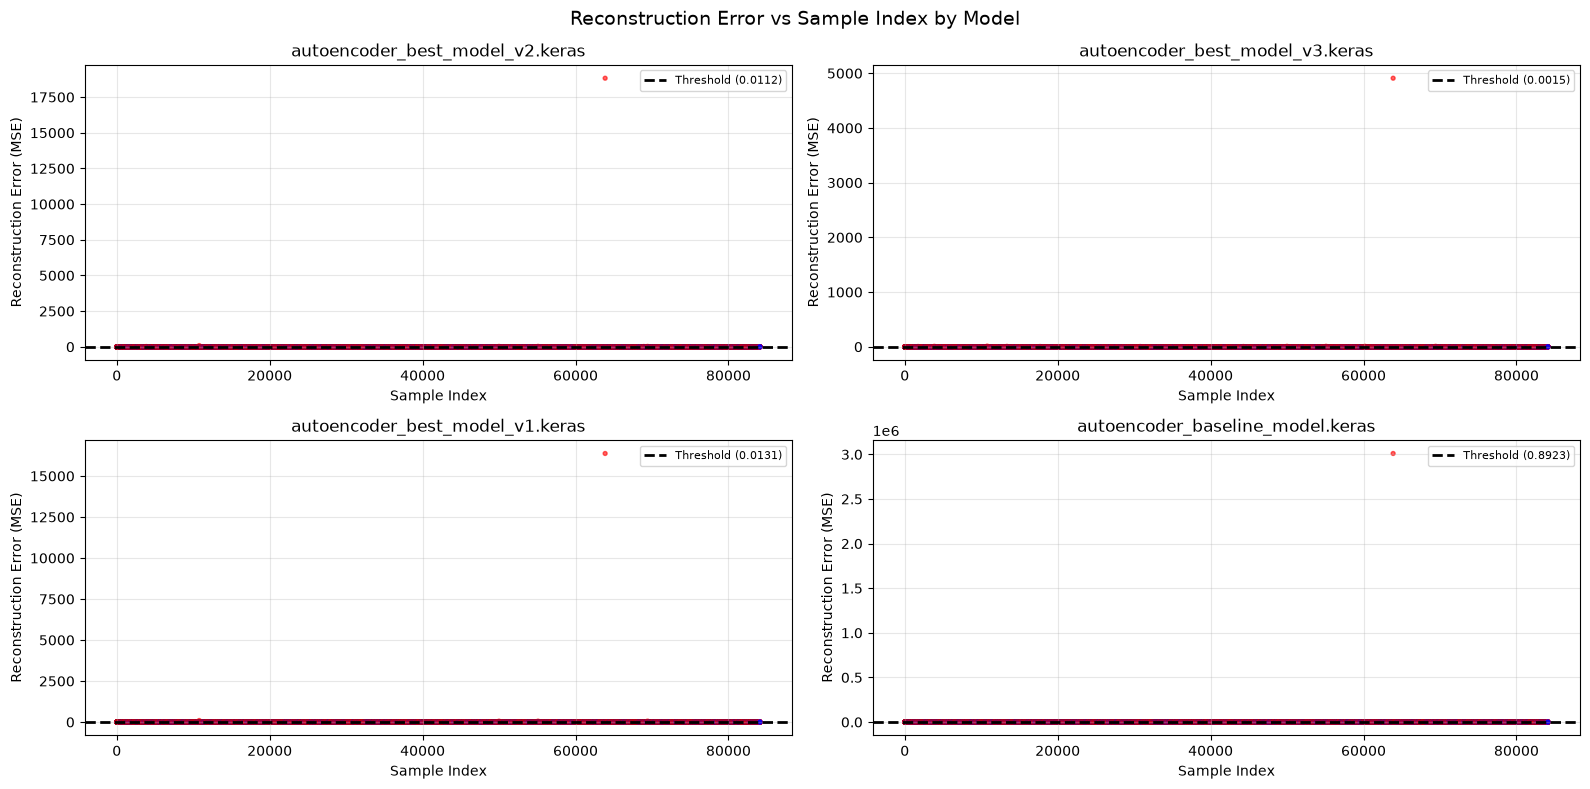


--- autoencoder_best_model_v2.keras ---


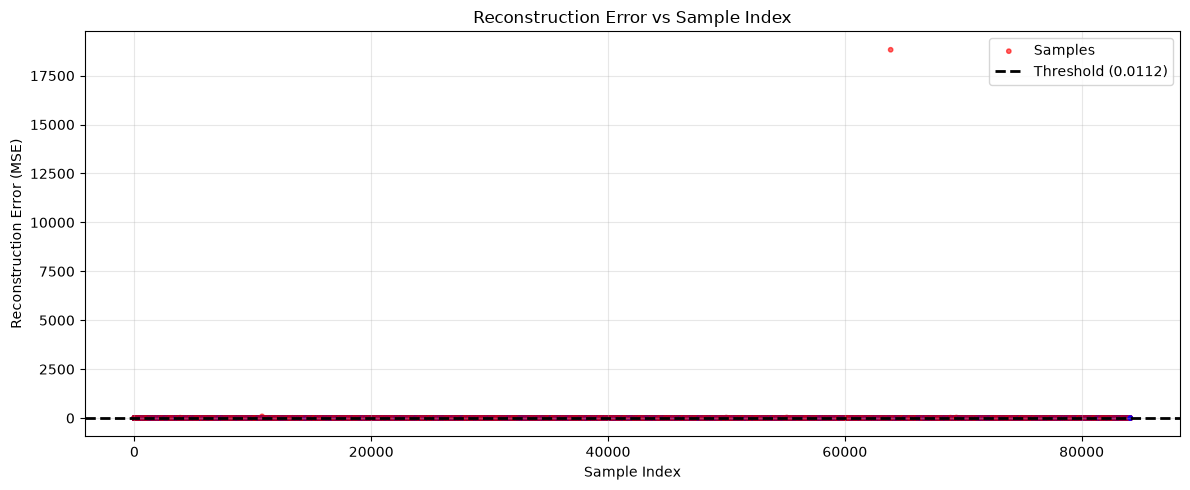


--- autoencoder_best_model_v3.keras ---


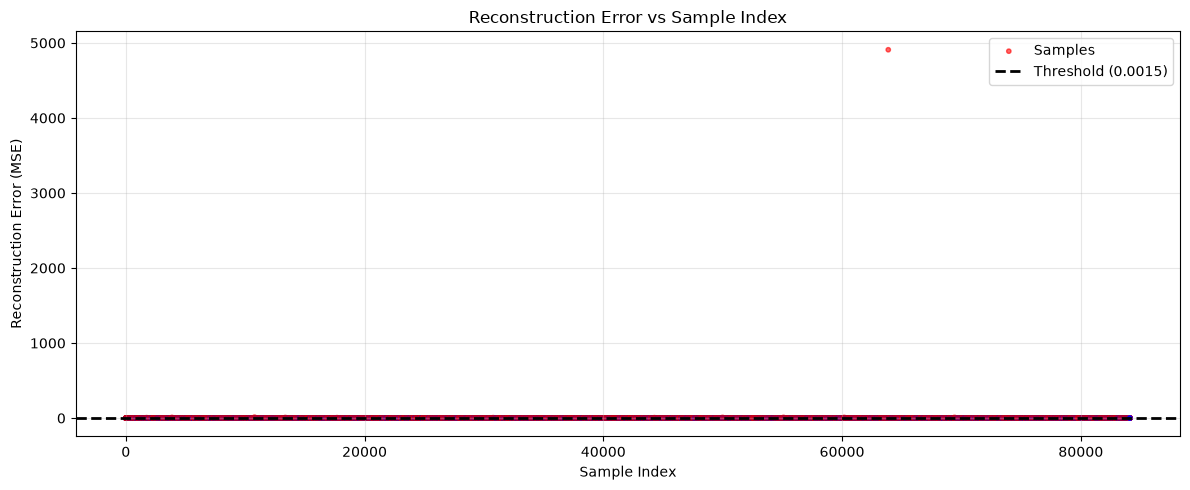


--- autoencoder_best_model_v1.keras ---


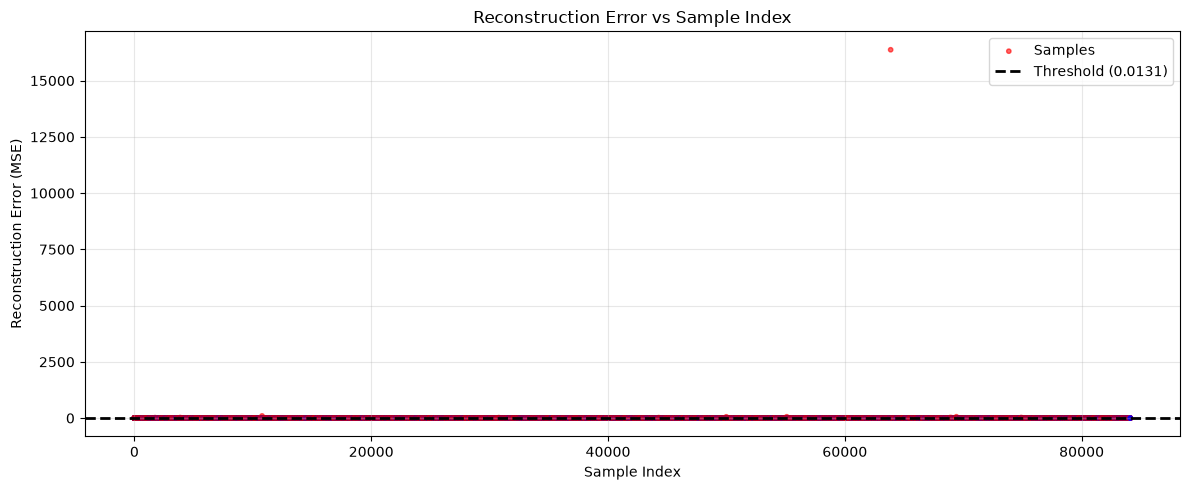


--- autoencoder_baseline_model.keras ---


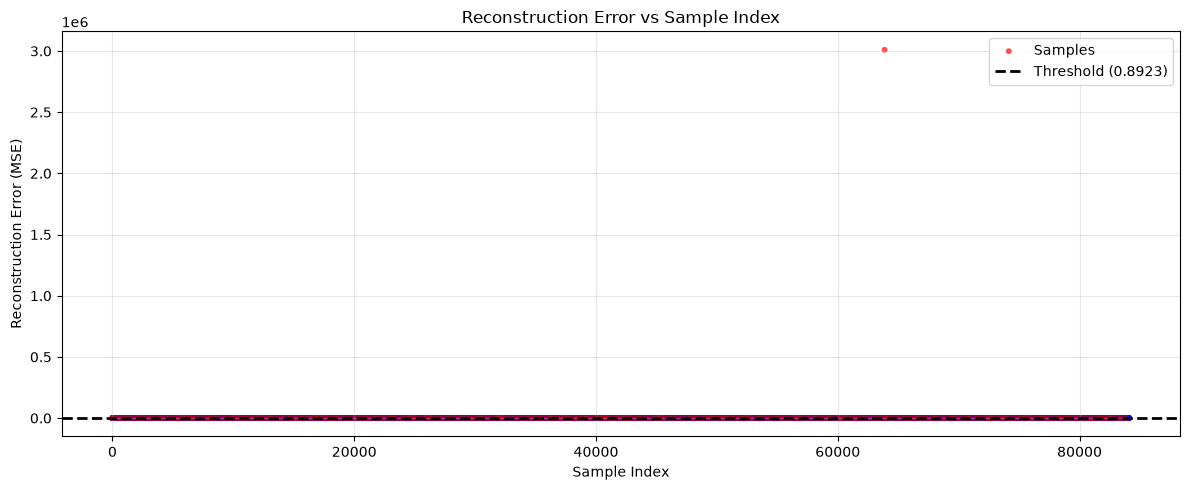

In [33]:
print("=" * 60)
print("RECONSTRUCTION ERROR VS SAMPLE INDEX - ALL MODELS")
print("=" * 60)

# Single comparison figure: one scatter plot per model
plot_reconstruction_error_vs_index_comparison(model_data)

# Individual full-size scatter plot for each model
for model_name, data in model_data.items():
    print(f"\n--- {model_name} ---")
    plot_reconstruction_error_vs_index(
        test_errors=data['test_errors'],
        y_pred=data['y_pred'],
        threshold=data['threshold'],
    )

# Section 6: Comprehensive Report
Generate a single comprehensive evaluation report containing the metrics, threshold, and
confusion matrix details for every model, ranked by F1-score.

In [34]:
# =============================================================================
# SECTION 6: COMPREHENSIVE EVALUATION REPORT - ALL MODELS
# =============================================================================

print("=" * 60)
print("COMPREHENSIVE EVALUATION REPORT - ALL MODELS")
print("=" * 60)

# Rank models by F1-score, then build a single combined report string
models_by_f1 = sorted(
    model_data.items(), key=lambda kv: kv[1]['metrics']['f1_score'], reverse=True
)

report_sections = []
for model_name, data in models_by_f1:
    header = f"MODEL: {model_name}"
    report_sections.append(header + "\n" + "#" * len(header))
    report_sections.append(
        build_evaluation_report(
            metrics=data['metrics'],
            threshold=data['threshold'],
            percentile=PERCENTILE,
        )
    )

combined_report_text = "\n\n".join(report_sections)
print(combined_report_text)

COMPREHENSIVE EVALUATION REPORT - ALL MODELS
MODEL: autoencoder_best_model_v3.keras
######################################

AUTOENCODER ANOMALY DETECTION - EVALUATION REPORT

Threshold Percentile: 95.0
Anomaly Threshold:    0.00148778

CLASSIFICATION METRICS
------------------------------
Accuracy:  0.980096
Precision: 0.978090
Recall:    0.993265
F1-Score:  0.985619

CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     26350
           1       0.98      0.99      0.99     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.98     84104
weighted avg       0.98      0.98      0.98     84104


CONFUSION MATRIX
------------------------------
[[25065  1285]
 [  389 57365]]

End of Report


MODEL: autoencoder_best_model_v1.keras
######################################

AUTOENCODER ANOMALY DETECTION - EVALUATION REPORT

Threshold Percentile: 

# Section 7: Per-Class / Per-Attack Analysis

Analyze detection performance per attack category for every model, and present the
per-attack detection rates for all models side-by-side in a single pivot table.

In [35]:
# Load original categorical labels from the test set
test_labels_categorical = test_set['label'].values
unique_attacks = np.unique(test_labels_categorical)

print(f"Unique attack types in test set: {unique_attacks}")
print(f"Count per type:\n{pd.Series(test_labels_categorical).value_counts()}")


def _detection_rate(attack, y_pred_attack):
    # For normal class, we want 0 predictions (correct = normal)
    # For attack classes, we want 1 predictions (correct = anomaly)
    correct_label = 0 if attack == 'normal' else 1
    total = len(y_pred_attack)
    correct = int(np.sum(y_pred_attack == correct_label))
    return correct / total if total > 0 else np.nan


# Compute per-attack detection rates for every model
per_attack_rows = []
for attack in unique_attacks:
    mask = (test_labels_categorical == attack)
    row = {'attack': attack, 'type': 'normal' if attack == 'normal' else 'attack', 'total': int(np.sum(mask))}
    for model_name, data in model_data.items():
        row[model_name] = _detection_rate(attack, data['y_pred'][mask])
    per_attack_rows.append(row)

# Single pivot table: rows = attack type, columns = detection rate per model
per_attack_df = pd.DataFrame(per_attack_rows)
print(f"\nPercentile: {PERCENTILE} (per-model thresholds shown in Section 1)\n")
display(per_attack_df)

Unique attack types in test set: ['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']
Count per type:
neptune            51820
normal             26350
back                 968
teardrop             918
satan                906
warezclient          893
ipsweep              651
smurf                641
portsweep            416
pod                  206
nmap                 158
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  19
imap                  12
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Percentile: 95.0 (per-model thresholds shown in Section 1)



,attack,type,total,autoencoder_best_model_v2.keras,autoencoder_best_model_v3.keras,autoencoder_best_model_v1.keras,autoencoder_baseline_model.keras
0,back,attack,968,0.793388,1.000000,0.851240,0.013430
1,buffer_overflow,attack,30,0.800000,0.800000,0.800000,0.733333
2,ftp_write,attack,8,0.750000,0.750000,0.750000,0.500000
3,guess_passwd,attack,53,1.000000,1.000000,1.000000,1.000000
4,imap,attack,12,1.000000,1.000000,1.000000,0.916667
5,ipsweep,attack,651,1.000000,1.000000,1.000000,0.861751
6,land,attack,19,1.000000,1.000000,1.000000,1.000000
7,loadmodule,attack,9,1.000000,1.000000,1.000000,0.666667
8,multihop,attack,7,1.000000,0.857143,1.000000,0.857143
9,neptune,attack,51820,1.000000,1.000000,1.000000,0.999961


# Section 8: Threshold Sensitivity Analysis

Analyze how metrics change across different threshold percentiles for every model, to
understand the trade-off between precision and recall, overlaid in a single comparison
figure, plus each model's individual full-size sensitivity plot.

Computing threshold sensitivity for all models...


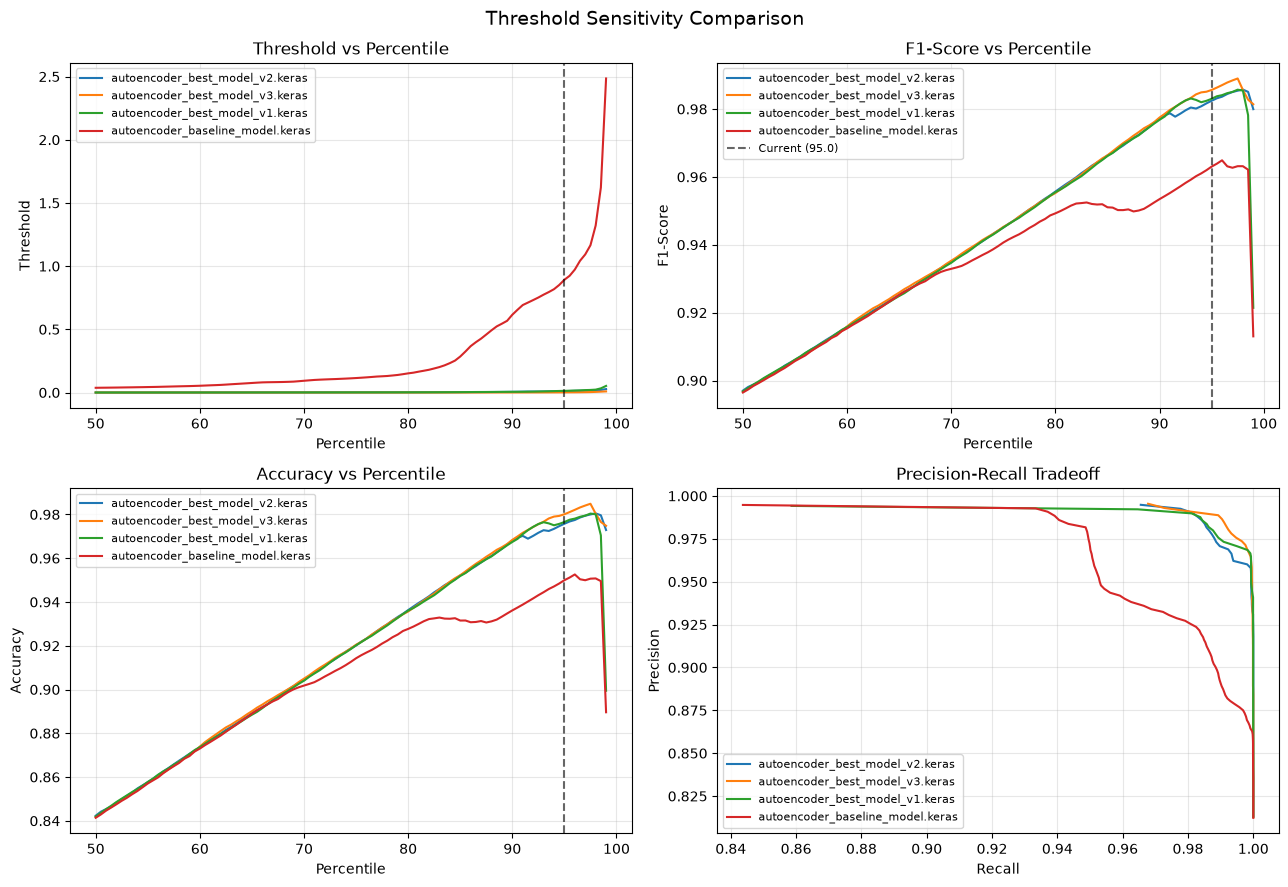


--- autoencoder_best_model_v2.keras ---


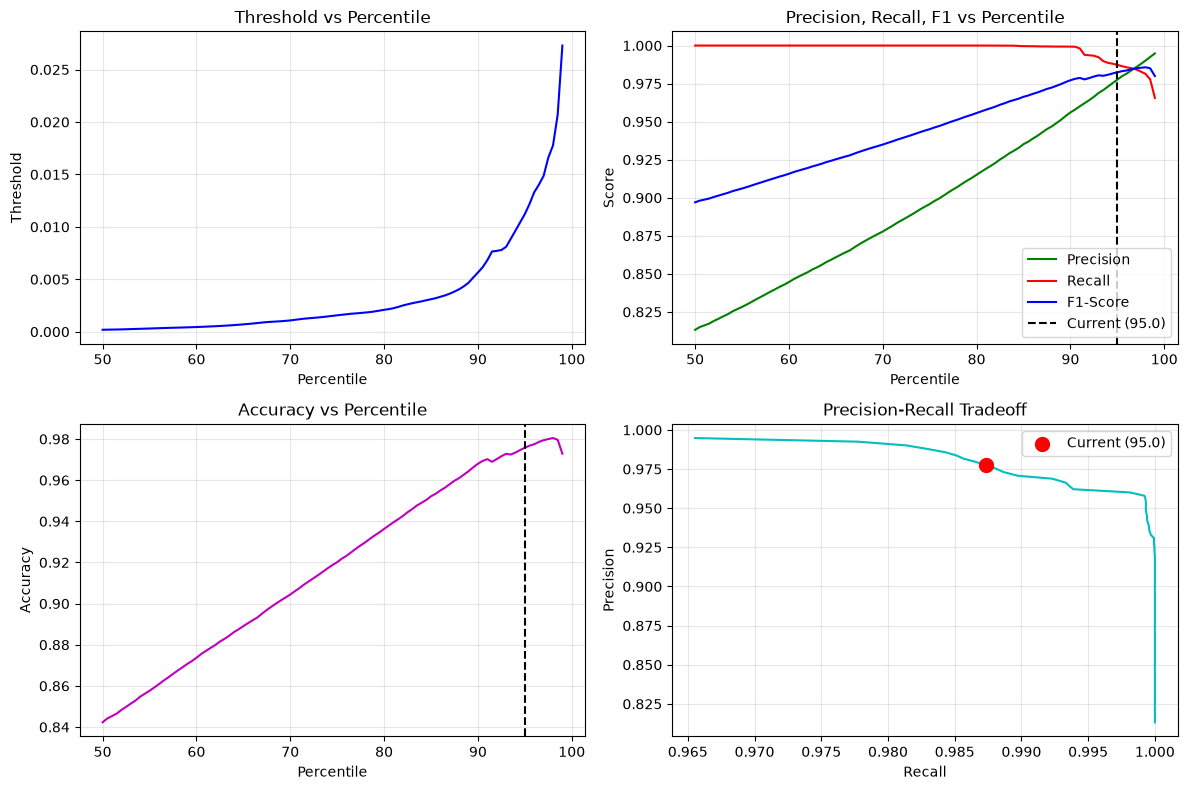


--- autoencoder_best_model_v3.keras ---


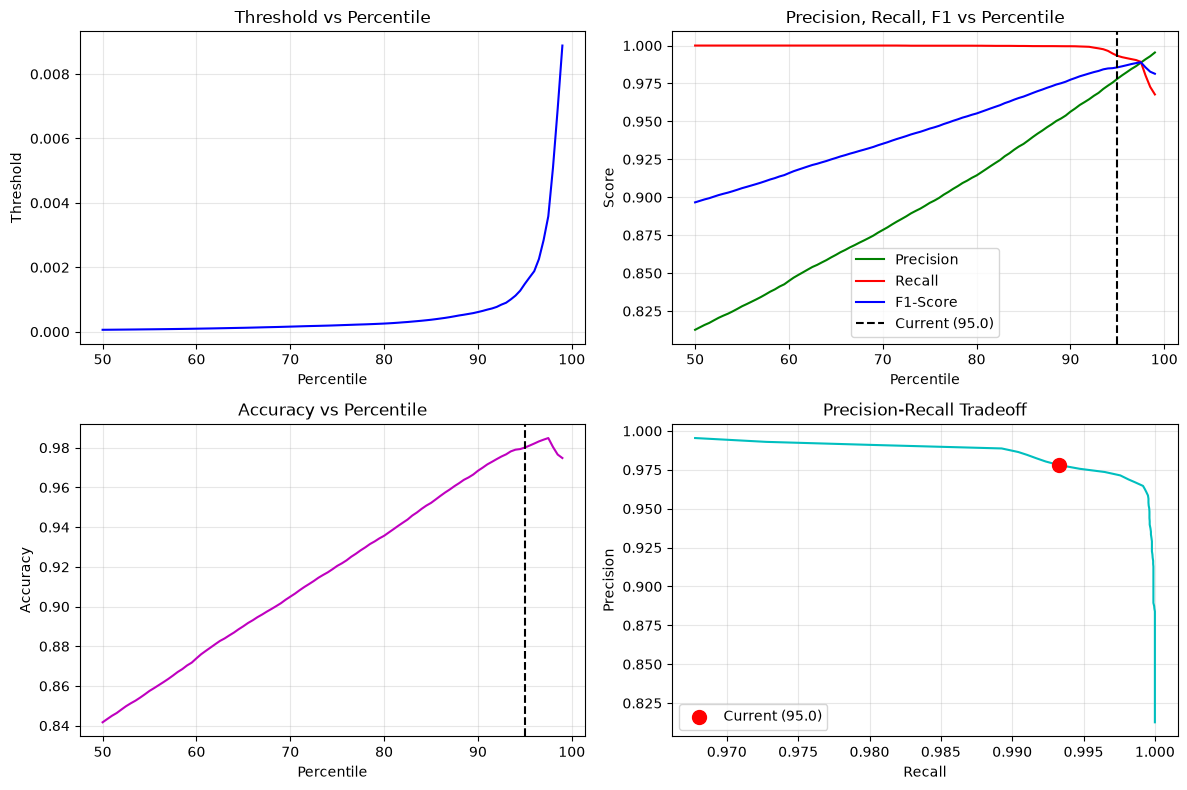


--- autoencoder_best_model_v1.keras ---


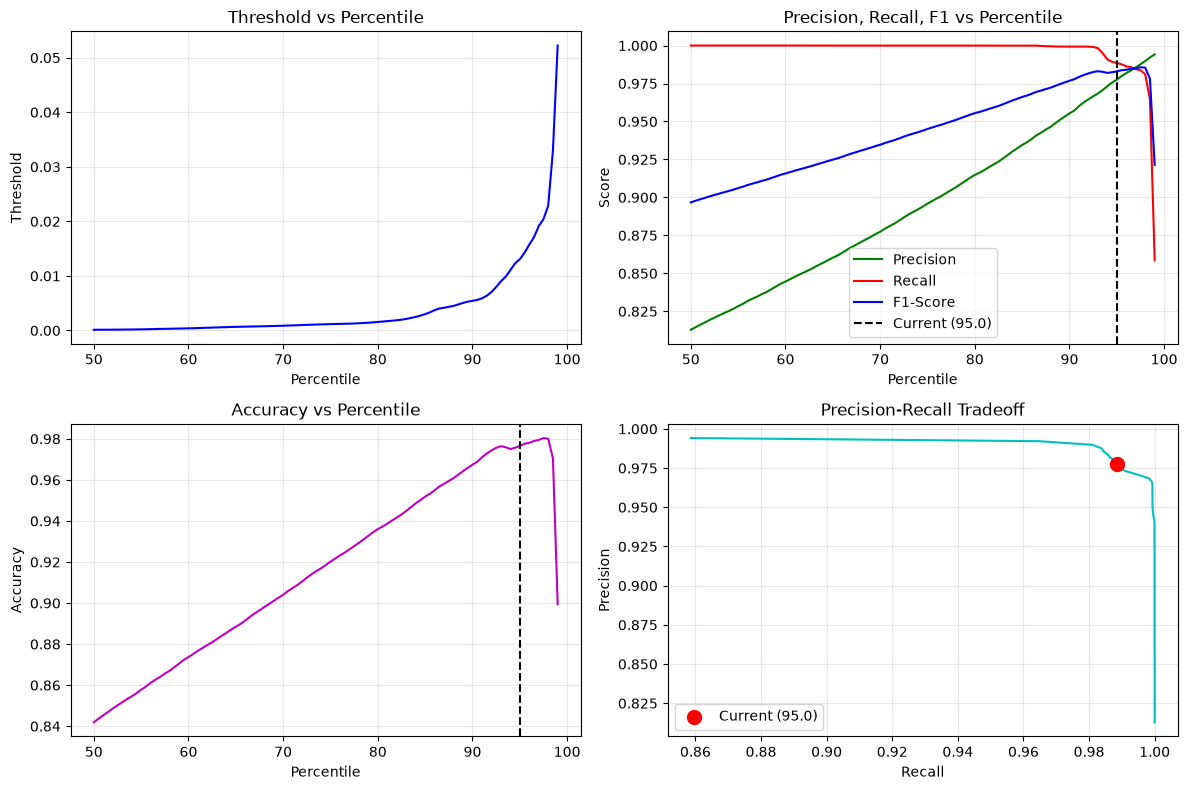


--- autoencoder_baseline_model.keras ---


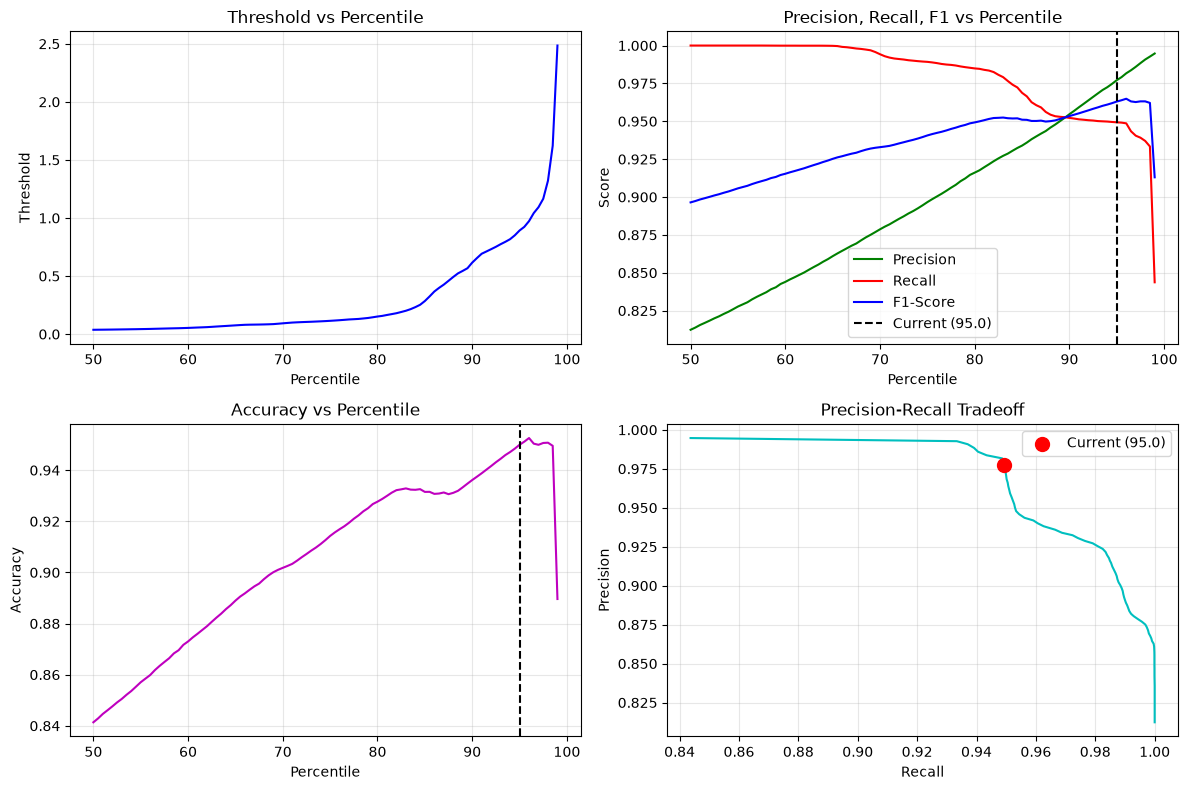

,model_name,best_f1_score,best_percentile,best_threshold,current_f1_score,current_percentile
0,autoencoder_best_model_v3.keras,0.988999,97.5,0.003587,0.985619,95.0
1,autoencoder_best_model_v2.keras,0.985721,98.0,0.017765,0.982435,95.0
2,autoencoder_best_model_v1.keras,0.985705,97.5,0.020418,0.983014,95.0
3,autoencoder_baseline_model.keras,0.964883,96.0,0.973024,0.963035,95.0


In [36]:
percentiles = np.arange(50, 99.5, 0.5)

print("Computing threshold sensitivity for all models...")
sensitivity_by_model = {}
for model_name, data in model_data.items():
    train_errors = data['train_errors']
    test_errors = data['test_errors']
    sensitivity_results = []
    for p in percentiles:
        thresh = select_anomaly_threshold(train_errors, percentile=p)
        y_pred_p = predict_anomalies(test_errors, thresh)
        m = compute_anomaly_metrics(y_test, y_pred_p)
        sensitivity_results.append({
            'percentile': p,
            'threshold': thresh,
            'accuracy': m['accuracy'],
            'precision': m['precision'],
            'recall': m['recall'],
            'f1_score': m['f1_score']
        })
    sensitivity_by_model[model_name] = pd.DataFrame(sensitivity_results)

# Single comparison figure: threshold/F1/accuracy vs percentile and the
# precision-recall tradeoff, one line per model in each subplot
plot_threshold_sensitivity_comparison(sensitivity_by_model, current_percentile=PERCENTILE)

# Individual full-size sensitivity plot for each model
for model_name, sdf in sensitivity_by_model.items():
    print(f"\n--- {model_name} ---")
    plot_threshold_sensitivity(sdf, current_percentile=PERCENTILE)

# Single summary table: best achievable F1-score (and its percentile) per model,
# compared against the F1-score at the currently configured percentile
best_vs_current_rows = []
for model_name, sdf in sensitivity_by_model.items():
    best_row = sdf.loc[sdf['f1_score'].idxmax()]
    current_f1 = model_data[model_name]['metrics']['f1_score']
    best_vs_current_rows.append({
        'model_name': model_name,
        'best_f1_score': best_row['f1_score'],
        'best_percentile': best_row['percentile'],
        'best_threshold': best_row['threshold'],
        'current_f1_score': current_f1,
        'current_percentile': PERCENTILE,
    })

display(pd.DataFrame(best_vs_current_rows).sort_values('best_f1_score', ascending=False).reset_index(drop=True))